<a href="https://colab.research.google.com/github/Egorrvd/tip2_1/blob/main/Primat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Часть I. Подготовка к взлету и нелинейные уравнения

---




## Задание: Расчет вращающего момента при взлете

Разложите тягу $T_{\text{орб}}$ на горизонтальную и вертикальную составляющие и запишите общий момент вращения, действующий в точке $G$.
Полученный момент нам хочется приравнять к нулю, чтобы обеспечить отсутствие вращения нашей ракеты при взлете.

---



## Задание: Визуализация и анализ момента

Постройте график общего момента $M$ в зависимости от угла $\theta$.

1. **Построить график** зависимости $M(\theta)$.
2. **Прикинуть визуально**, в какой точке график пересекается с нулем ($M = 0$).
3. **Оценить начальное приближение** (стартовое значение $\theta_0$) для дальнейшего численного или аналитического решения уравнения.
---

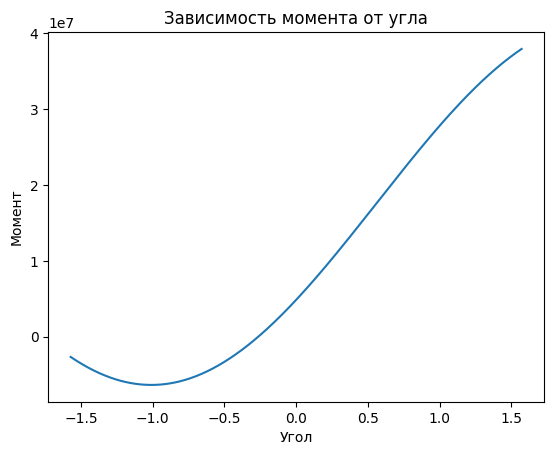

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def moment(theta, y_orb=11.6, T_usk=14.7*1e6, T_orb=1.75*1e6, x_usk=1.2, x_orb=7.3):
    return T_usk*x_usk - x_orb*T_orb*np.cos(theta) + y_orb*T_orb*np.sin(theta)

# Зависимость момента от угла
x = np.linspace(-np.pi/2, np.pi/2, 1000)
plt.title('Зависимость момента от угла')
plt.xlabel('Угол')
plt.ylabel('Момент')
plt.plot(x, moment(x))

plt.show()




## Метод бисекции

При расчете устойчивости ракеты нам необходимо найти такой угол наклона двигателя $\theta$, при котором суммарный вращающий момент равен нулю: $M(\theta) = 0$. Для решения этого нелинейного уравнения мы используем один из самых надежных численных методов — **метод бисекции** (или метод деления отрезка пополам).

---

## 1. Теория.

Метод бисекции применяется для поиска корней непрерывной функции $f(x)$ на заданном отрезке $[a, b]$, если на его концах функция принимает значения разных знаков (то есть $f(a) \cdot f(b) < 0$). По теореме Больцано-Коши это гарантирует, что внутри отрезка есть хотя бы один корень.

### Алгоритм:
1. **Нахождение середины отрезка:** Вычисляется центральная точка $c = \frac{a + b}{2}$.
2. **Точный корень:** Если $f(c) = 0$, то корень найден.
3. **Сужение интервала:**
* Если $f(a) \cdot f(c) < 0$, значит, корень находится в левой половине, и мы сдвигаем правую границу: $b = c$.
* Иначе корень находится в правой половине, и мы сдвигаем левую границу: $a = c$.
4. **Критерий остановки:** Процесс повторяется циклически, пока длина отрезка не станет меньше заданной погрешности ($\frac{b - a}{2} \le \text{погрешность}$).

---



In [ ]:
def bisect_solve(func, a, b, tol=1e-6):
    if func(a) * func(b) >= 0:
        print("на интервале нет нуля")
        return None
    iter = 0
    while (b - a) / 2.0 > tol:
        iter += 1
        mid = (a + b) / 2.0
        if func(mid) == 0:
            return mid
        elif func(a) * func(mid) < 0:
            b = mid
        else:
            a = mid

    return (a + b) / 2.0, iter


root, iter = bisect_solve(moment, -0.5, 0.5)
print(f"угол theta: {root} радиан, за {iter} итераций")

угол theta: -0.26464176177978516 радиан, за 19 итераций


## Метод Ньютона

В отличие от метода бисекции, этот подход использует информацию не только о значении функции, но и о скорости её изменения (производной).

---

## 1. Теория

Метод Ньютона — это итерационный численный метод поиска корней. Вместо простого деления отрезка пополам, он аппроксимирует исходную функцию касательной линией в текущей точке и ищет точку пересечения этой касательной с осью $X$.



### Алгоритм:
1. Выбирается стартовая точка $x_0$.
2. В точке $(x_0, f(x_0))$ к графику функции проводится касательная. Уравнение этой касательной имеет вид:
   $$y = f(x_0) + f'(x_0)(x - x_0)$$
3. Следующее приближение $x_1$ — это точка, где данная касательная пересекает ось $X$ ($y = 0$). Формула метода Ньютона:
   $$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$
4. Процесс повторяется, пока не выполнится критерий остановки: расстояние между соседними шагами станет меньше заданной погрешности
* ($|x_{n+1} - x_n| < \text{погрешность}$).


угол theta: -0.264642 радиан, за 4 итераций
это -15.1629 градусов


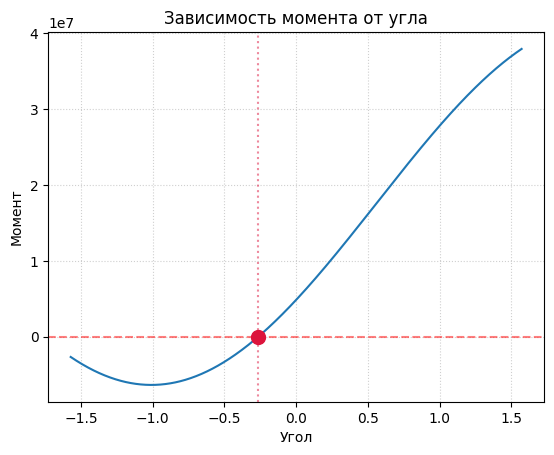

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#константы

Y_ORB = 11.6
T_USK = 14.7 * 1e6
T_ORB = 1.75 * 1e6
X_USK = 1.2
X_ORB = 7.3

def moment(theta):

    #момент сил M(theta).

    return T_USK * X_USK - X_ORB * T_ORB * np.cos(theta) + Y_ORB * T_ORB * np.sin(theta)

def moment_derivative(theta):

    #производная момента M'(theta) по углу theta.

    return X_ORB * T_ORB * np.sin(theta) + Y_ORB * T_ORB * np.cos(theta)

def newton_solve(func, dfunc, x0, tol=1e-6, max_iter=100):
    x = x0
    iter_count = 0

    for i in range(max_iter):
        iter_count += 1
        fx = func(x)
        dfx = dfunc(x)

        if abs(dfx) < 1e-12:
            print("Производная равна нулю")
            return None, iter_count

        x_new = x - fx / dfx

        if abs(x_new - x) < tol:
            return x_new, iter_count

        x = x_new

    print("Превышено максимальное число итераций")
    return x, iter_count

# график

# Зависимость момента от угла
x = np.linspace(-np.pi/2, np.pi/2, 1000)
plt.title('Зависимость момента от угла')
plt.xlabel('Угол')
plt.ylabel('Момент')
plt.plot(x, moment(x))
plt.grid(True, linestyle=':', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)

# Решение методом Ньютона
root, iter_count = newton_solve(moment, moment_derivative, x0=0.0, tol=1e-6)

if root is not None:
    # Отмечаем корень на графике
    plt.scatter(root, 0, color='crimson', s=100, zorder=5)
    plt.axvline(root, color='crimson', linestyle=':', alpha=0.5)

    print(f"угол theta: {root:.6f} радиан, за {iter_count} итераций")
    print(f"это {root * 180 / np.pi:.4f} градусов")
else:
    print("Метод Ньютона не сошёлся")

plt.show()

# Часть II. Миссия «Достигнуть орбиты»: Интегрирование и дифференцирование

---



1. **Расчет времени взлета:** Найти время $t$, за которое ракета достигнет первой космической скорости ($v(t) = v_{I}$), решив уравнение численным методом.
2. **Расчет высоты (Интегрирование):** Численно проинтегрировать функцию скорости $v(t)$ от $0$ до найденного времени не менее чем двумя методами, чтобы узнать высоту подъема и определить, выйдет ли ракета на орбиту.

3. **Расчет перегрузок:** Численно продифференцировать профиль скорости двумя способами. Построить графики ускорения.

4. **Расчет «дерганности»:** Продифференцировать профиль скорости еще раз (найти третью производную координаты по времени)

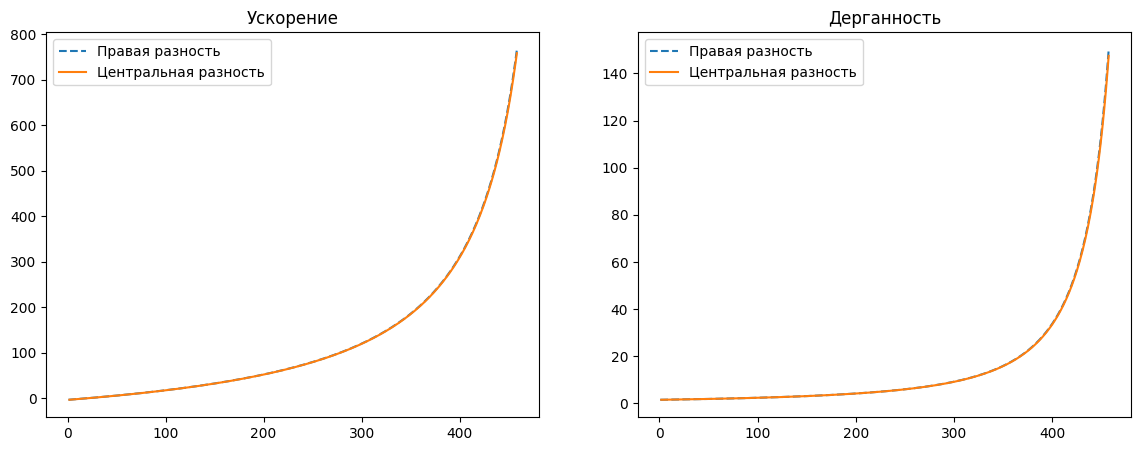

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры
u = 4800          # м/с
q = 4000         # кг/с
m0 = 2041000      # кг
g = 9.81          # м/с^2
t_max = (m0 * 0.9) / q
t_vals = np.linspace(1, t_max, 500)
h = 0.1

def v(t):
    return u * np.log(m0 / (m0 - q * t)) - g * t



#Ускорение
a_right = (v(t_vals[1:]) - v(t_vals[:-1])) / h
t_right = t_vals[:-1]

a_center = (v(t_vals[2:]) - v(t_vals[:-2])) / (2 * h)
t_center = t_vals[1:-1]

# Дерганность
jerk_right = np.diff(a_right) / h
jerk_center = np.diff(a_center) / h

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#Ускорение
ax1.plot(t_right, a_right, label='Правая разность', linestyle='--')
ax1.plot(t_center, a_center, label='Центральная разность')
ax1.set_title('Ускорение')
ax1.legend()

# Дерганность
ax2.plot(t_right[:-1], jerk_right, label='Правая разность', linestyle='--')
ax2.plot(t_center[:-1], jerk_center, label='Центральная разность')
ax2.set_title('Дерганность')
ax2.legend()

plt.show()

# Часть III. Движение по орбите и метод наименьших квадратов

---

## Практическое задание: Аппроксимация орбиты с помощью МНК

### 1. Подготовка данных
1. Задать некоторый исходный эллипс и зашумить его (добавить к координатам точек случайную погрешность)
2. Выделить определенную часть и записать функцию с явным математическим заданием

### 2. Реализация рекурсивного МНК



**Обычный МНК:**
* **Принцип:** Накапливает координаты $(x, y)$ за весь полет и считает их одной пачкой.
* С ростом точек матрицы разрастаются, вычисления замедляются, а при новой точке всю задачу приходится пересчитывать с нуля.

**Рекурсивный МНК:**
* **Принцип:** Обновляет параметры орбиты при поступлении каждого нового измерения.
* Не хранит историю точек. Размер матриц фиксирован, а вычислительная нагрузка стабильна и минимальна на каждом шаге.


Оценка параметров: a=9.91, b=5.03


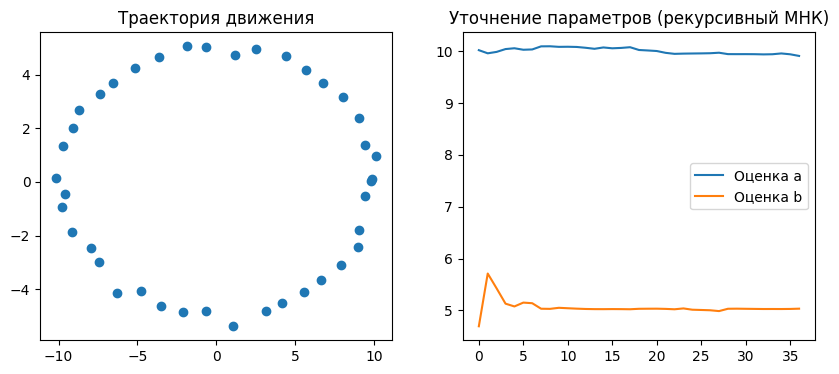

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Генерация элипса
def generate_orbit(n=40):
    t = np.linspace(0, 2*np.pi, n)
    a, b = 10, 5  # Параметры эллипса
    x = a * np.cos(t) + np.random.normal(0, 0.2, n)
    y = b * np.sin(t) + np.random.normal(0, 0.2, n)
    return x, y

#МНК: оценка параметров эллипса x^2/a^2 + y^2/b^2 = 1
#преобразуем уравнение: A*x^2 + B*y^2 = 1
def least_squares_fit(x, y):
    # Матрица признаков: X = [x^2, y^2]
    X = np.vstack([x**2, y**2]).T
    Y = np.ones(len(x))
    # Решение системы
    params = np.linalg.inv(X.T @ X) @ X.T @ Y
    return 1/np.sqrt(params[0]), 1/np.sqrt(params[1])

#Реализация рекурсивного МНК
def recursive_ls(x, y):
    a_est, b_est = [], []
    for i in range(3, len(x)):
        a, b = least_squares_fit(x[:i], y[:i])
        a_est.append(a)
        b_est.append(b)
    return a_est, b_est


x_data, y_data = generate_orbit()
a_fit, b_fit = least_squares_fit(x_data, y_data)
a_history, b_history = recursive_ls(x_data, y_data)

print(f"Оценка параметров: a={a_fit:.2f}, b={b_fit:.2f}")

# Графики
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(x_data, y_data, label='Данные с шумом')
plt.title('Траектория движения')

plt.subplot(1, 2, 2)
plt.plot(a_history, label='Оценка a')
plt.plot(b_history, label='Оценка b')
plt.title('Уточнение параметров (рекурсивный МНК)')
plt.legend()
plt.show()

# Часть IV: Возврат на Землю и интерполяция + практический эксперимент


1. **Проведение эксперимента:** Сложить бумажный самолетик, запустить его вдоль измерительного экрана (стены/доски) и зафиксировать координаты нескольких точек его полета в плоскости.
2. **Интерполяция Лагранжа:** Построить интерполяционный многочлен Лагранжа по полученным экспериментальным точкам.
3. **Анализ числа узлов:** Рассмотреть 3 кардинально различных набора точек (изменяя их количество), сравнить реальную траекторию самолетика с построенными приближениями и сделать выводы об удачности интерполяции.
4. **Поиск точки падения:** Найти координату пересечения самолетика с землей (экстраполяция траектории), решив уравнение $L(z)=0$.


Набор 1: Точка приземления z = 220.00 см
Набор 2: Точка приземления z = 197.64 см
Набор 3: Точка приземления z = 220.00 см


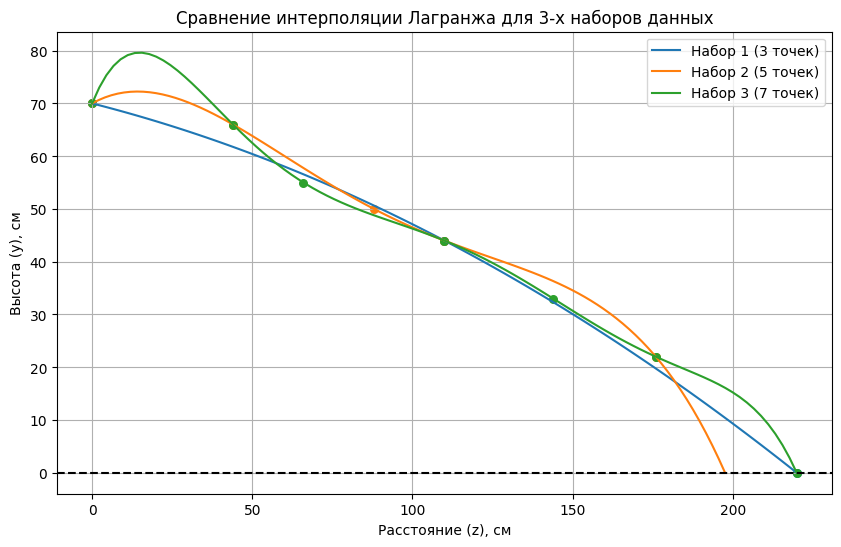

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange
from scipy.optimize import bisect


data = [
    {'x': [0, 110, 220], 'y': [70, 44, 0]},      # 3 точки
    {'x': [0, 44, 88, 110, 176], 'y': [70, 66, 50, 44, 22]}, # 5 точек
    {'x': [0, 44, 66, 110, 144, 176, 220], 'y': [70, 66, 55, 44, 33, 22, 0]} # 7 точек
]

plt.figure(figsize=(10, 6))

for i, data in enumerate(data):
    x_nodes = np.array(data['x'])
    y_nodes = np.array(data['y'])

    #Построение полинома Лагранжа
    poly = lagrange(x_nodes, y_nodes)

    try:
        landing_z = bisect(poly, x_nodes[0], x_nodes[-1] + 50)
        print(f"Набор {i+1}: Точка приземления z = {landing_z:.2f} см")
    except ValueError:
        print(f"Набор {i+1}: Не удалось найти точку приземления (нужны другие точки)")
        landing_z = x_nodes[-1]

    # 3. Визуализация
    x_range = np.linspace(x_nodes[0], landing_point_visual := max(landing_z, x_nodes[-1]), 100)
    plt.plot(x_range, poly(x_range), label=f'Набор {i+1} ({len(x_nodes)} точек)')
    plt.scatter(x_nodes, y_nodes, s=30)

# Оформление графика
plt.axhline(0, color='black', linestyle='--')
plt.title('Сравнение интерполяции Лагранжа для 3-х наборов данных')
plt.xlabel('Расстояние (z), см')
plt.ylabel('Высота (y), см')
plt.legend()
plt.grid(True)
plt.show()